# Chapter 8: Hands-On Autoencoder

**Book:** *Hands-On Unsupervised Learning Using Python* — Ankur A. Patel (O'Reilly, 2019)  
**Audience:** Beginners  
**Goal:** Train multiple **autoencoder** architectures on MNIST (Modified National Institute of Standards and Technology) digits — undercomplete, nonlinear, overcomplete with dropout, sparse, and denoising — and compare **reconstruction MSE (Mean Squared Error)** on the test set.

---

## What you will learn

1. Prepare MNIST data — scale to [0, 1], train/test split
2. Build your **first undercomplete autoencoder** (784 → 32 → 784)
3. Train with **MSE loss** and **Adam optimizer**
4. Compare **two-layer linear**, **nonlinear (ReLU)**, **overcomplete + dropout**, **sparse**, and **denoising** variants
5. Evaluate **reconstruction error** on held-out test images
6. Visualize original vs reconstructed digits


## Setup — run this cell first

| Library | Purpose |
|---------|--------|
| **NumPy (Numerical Python)** | Arrays and math |
| **Pandas (Python Data Analysis Library)** | Results tables |
| **Matplotlib (Mathematical Plotting Library)** | Reconstruction plots |
| **TensorFlow 2.x / Keras 3** | Build and train autoencoders |
| **scikit-learn (Scientific Kit for Learning)** | Load MNIST, train/test split |


In [1]:
# Import warnings module so we can hide non-critical messages during demos
import warnings

# Hide TensorFlow/sklearn (scikit-learn) warnings to keep notebook output clean for beginners
warnings.filterwarnings("ignore")

# Import os to suppress verbose TensorFlow log messages
import os

# Set TensorFlow log level to errors only
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

# Import NumPy (Numerical Python) for fast numerical operations on arrays
import numpy as np

# Import Pandas (Python Data Analysis Library) for organizing comparison results
import pandas as pd

# Import Matplotlib (Mathematical Plotting Library) for creating charts
import matplotlib.pyplot as plt

# Import TensorFlow 2.x — deep learning backend
import tensorflow as tf

# Import Keras 3 high-level API from TensorFlow
from tensorflow import keras

# Import regularizers for sparse autoencoder activity penalty
from tensorflow.keras import regularizers

# Import MNIST (Modified National Institute of Standards and Technology) loader and digit fallback
from sklearn.datasets import fetch_openml, load_digits

# Import train_test_split for held-out evaluation
from sklearn.model_selection import train_test_split

# Import display() for rich table output inside Jupyter (Julia, Python, and R notebook environment)
from IPython.display import display

# Fix random seeds for reproducible training and data splits
RANDOM_STATE = 2018

np.random.seed(RANDOM_STATE)

tf.random.set_seed(RANDOM_STATE)

# Hyperparameters tuned for CPU execution under ~3 minutes total
N_SAMPLES = 4000

EPOCHS_MAIN = 10

EPOCHS_VARIANT = 6

BATCH_SIZE = 256

INPUT_DIM = 784

# Print environment info
print(f"TensorFlow {tf.__version__}  |  Keras {keras.__version__}")

print("Libraries loaded successfully.")


TensorFlow 2.21.0  |  Keras 3.14.1
Libraries loaded successfully.


---

## Libraries Imported in This Notebook

| Library | What it does | Why we use it here |
|---------|--------------|-------------------|
| **NumPy (Numerical Python)** (`np`) | Fast math on arrays | Store flattened digit images |
| **Pandas (Python Data Analysis Library)** (`pd`) | Spreadsheet-like DataFrames | Compare reconstruction MSE across models |
| **Matplotlib (Mathematical Plotting Library)** (`plt`) | Charts and image display | Show original vs reconstructed digits |
| **TensorFlow / Keras** | Neural network training | Build encoder-decoder models |
| **keras.regularizers** | L1/L2 penalties on activations | Sparse autoencoder |
| **sklearn.datasets** | Built-in datasets | Load MNIST subset |
| **sklearn.model_selection.train_test_split** | Random split | Train vs test evaluation |


---

## Algorithms Used in This Notebook

### 1. Undercomplete Autoencoder (784 → 32 → 784)
- **Type:** Feedforward autoencoder with narrow bottleneck
- **Loss:** MSE (Mean Squared Error) between input and reconstruction
- **Optimizer:** Adam (adaptive learning rate)

### 2. Two-Layer Undercomplete (Linear Activation)
- **Architecture:** 784 → 64 → 32 → 64 → 784 with linear hidden activations
- **Book reference:** Deeper linear bottleneck before nonlinear variants

### 3. Nonlinear Autoencoder (ReLU)
- **Architecture:** Same shape but ReLU (Rectified Linear Unit) in hidden layers
- **Captures:** Nonlinear pixel combinations for better reconstructions

### 4. Overcomplete Autoencoder + Dropout
- **Architecture:** Bottleneck **larger** than compression need (784 → 128 → 256 → 128 → 784)
- **Dropout:** Randomly zeroes units during training to prevent memorization

### 5. Sparse Overcomplete Autoencoder
- **Activity regularizer:** L1 penalty on hidden activations encourages sparsity

### 6. Denoising Autoencoder
- **Input:** Clean digits + Gaussian noise
- **Target:** Clean original digits
- **Layer:** `GaussianNoise` corrupts input at training time

### Evaluation note

Autoencoders are **unsupervised** — digit labels are **not** used during training. Labels appear only when plotting sample digits for context.


---

## 1. Data Preparation

Load MNIST (or `load_digits` fallback), scale pixels to **[0, 1]**, and split into train/test sets.

We use a **4,000-image subset** so all variants train quickly on CPU.


In [2]:
# Try to download MNIST 784 features from OpenML (online ML repository)
try:

    print("Loading MNIST (Modified National Institute of Standards and Technology) from OpenML — may take a minute...")

    mnist = fetch_openml("mnist_784", version=1, as_frame=False, parser="auto")

    X_full = mnist.data.astype(np.float32)

    y_full = mnist.target.astype(int)

    rng = np.random.RandomState(RANDOM_STATE)

    idx = rng.choice(len(y_full), size=N_SAMPLES, replace=False)

    X_raw = X_full[idx]

    y = y_full[idx]

    DATA_SOURCE = "MNIST 784 (subset)"

except Exception as e:

    print(f"MNIST download failed ({e}). Using sklearn load_digits fallback.")

    digits = load_digits()

    X_raw = digits.data.astype(np.float32)

    y = digits.target.astype(int)

    DATA_SOURCE = "load_digits (8x8 fallback)"

# Scale pixel values to [0, 1] — required for sigmoid output and stable training
X_scaled = X_raw / 255.0

# Update INPUT_DIM in case fallback dataset has different feature count
INPUT_DIM = X_scaled.shape[1]

# 80/20 train/test split — stratify by digit label for balanced classes
X_train, X_test, y_train, y_test = train_test_split(

    X_scaled, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y,

)

# Report dataset summary
print(f"Data source: {DATA_SOURCE}")

print(f"Input dimension: {INPUT_DIM}")

print(f"Train: {X_train.shape[0]} samples  |  Test: {X_test.shape[0]} samples")

print(f"Pixel range after scaling: [{X_scaled.min():.2f}, {X_scaled.max():.2f}]")


Loading MNIST (Modified National Institute of Standards and Technology) from OpenML — may take a minute...


Data source: MNIST 784 (subset)
Input dimension: 784
Train: 3200 samples  |  Test: 800 samples
Pixel range after scaling: [0.00, 1.00]


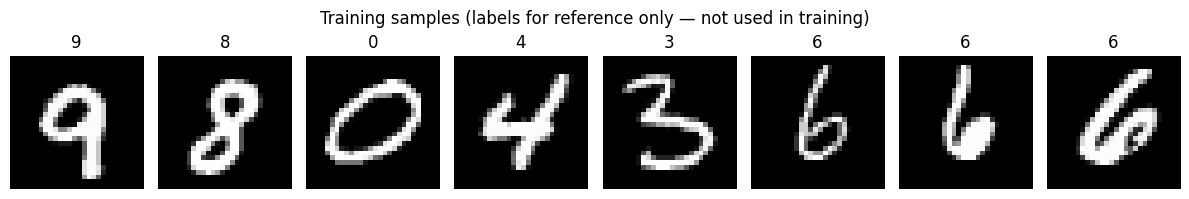

In [3]:
# Visualize a few training digits before autoencoder training
n_show = 8

fig, axes = plt.subplots(1, n_show, figsize=(12, 2))

side = int(np.sqrt(INPUT_DIM))

for ax, i in zip(axes, range(n_show)):

    ax.imshow(X_train[i].reshape(side, side), cmap="gray", vmin=0, vmax=1)

    ax.set_title(f"{y_train[i]}")

    ax.axis("off")

plt.suptitle("Training samples (labels for reference only — not used in training)")

plt.tight_layout()

plt.show()


---

## 2. Helper Functions

Reusable utilities to **build models**, **train**, **score test MSE**, and **plot reconstructions**.


In [4]:
# Define helper to compute reconstruction MSE (Mean Squared Error) on a dataset
def reconstruction_mse(model, X):

    # Predict reconstructions for all samples in X
    X_hat = model.predict(X, verbose=0)

    # Return mean squared error averaged over all pixels and samples
    return float(np.mean((X - X_hat) ** 2))


# Define helper to plot original vs reconstructed digits side by side
def plot_reconstructions(model, X, y_labels, n=8, title="Reconstructions"):

    # Get model reconstructions for first n test images
    X_hat = model.predict(X[:n], verbose=0)

    side = int(np.sqrt(X.shape[1]))

    fig, axes = plt.subplots(2, n, figsize=(14, 3.5))

    for i in range(n):

        # Top row: original digits
        axes[0, i].imshow(X[i].reshape(side, side), cmap="gray", vmin=0, vmax=1)

        axes[0, i].set_title(f"Orig {y_labels[i]}")

        axes[0, i].axis("off")

        # Bottom row: autoencoder reconstructions
        axes[1, i].imshow(X_hat[i].reshape(side, side), cmap="gray", vmin=0, vmax=1)

        axes[1, i].set_title("Recon")

        axes[1, i].axis("off")

    axes[0, 0].set_ylabel("Original", fontsize=11)

    axes[1, 0].set_ylabel("Reconstructed", fontsize=11)

    plt.suptitle(title)

    plt.tight_layout()

    plt.show()


# Define helper to compile and train any autoencoder with consistent settings
def train_autoencoder(model, X_tr, epochs, model_name="autoencoder"):

    # Compile with Adam optimizer and MSE loss — same as the book's first model
    model.compile(

        optimizer=keras.optimizers.Adam(learning_rate=0.001),

        loss="mse",

    )

    # Fit on training data — target equals input (standard autoencoder)
    history = model.fit(

        X_tr, X_tr,

        epochs=epochs,

        batch_size=BATCH_SIZE,

        validation_split=0.1,

        verbose=0,

    )

    # Report final training and validation loss
    print(f"{model_name}: final loss={history.history['loss'][-1]:.5f}, val_loss={history.history['val_loss'][-1]:.5f}")

    return history


---

## 3. Our First Autoencoder — 784 → 32 → 784

The book's first model: single hidden layer, **linear activation**, **undercomplete** bottleneck (32 units).

| Component | Choice |
|-----------|--------|
| **Loss** | MSE (Mean Squared Error) |
| **Optimizer** | Adam |
| **Output activation** | Sigmoid (matches [0, 1] pixel range) |


In [5]:
# Build first undercomplete autoencoder — encoder 784→32, decoder 32→784
ENCODING_DIM = 32

ae_input = keras.Input(shape=(INPUT_DIM,), name="input")

encoded = keras.layers.Dense(ENCODING_DIM, activation="linear", name="encoder")(ae_input)

decoded = keras.layers.Dense(INPUT_DIM, activation="sigmoid", name="decoder")(encoded)

autoencoder_v1 = keras.Model(ae_input, decoded, name="first_undercomplete_ae")

# Show architecture before training
autoencoder_v1.summary()


Model: "first_undercomplete_ae"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Dense)                 │ (None, 32)             │        25,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Dense)                 │ (None, 784)            │        25,872 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,992 (199.19 KB)

 Trainable params: 50,992 (199.19 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Train first autoencoder for EPOCHS_MAIN epochs
history_v1 = train_autoencoder(autoencoder_v1, X_train, EPOCHS_MAIN, "First AE (784→32→784)")

# Evaluate reconstruction MSE on held-out test set
mse_v1 = reconstruction_mse(autoencoder_v1, X_test)

print(f"Test reconstruction MSE: {mse_v1:.6f}")


First AE (784→32→784): final loss=0.05908, val_loss=0.05704


Test reconstruction MSE: 0.058224


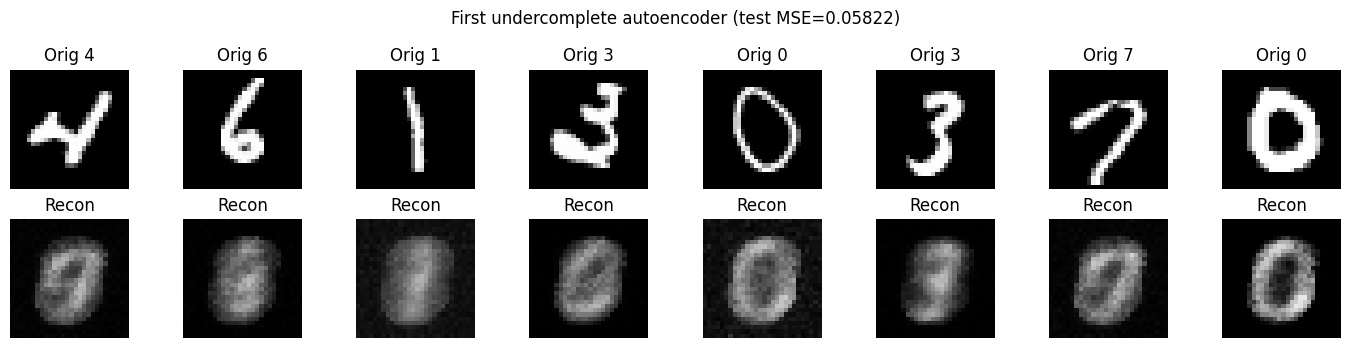

In [7]:
# Visualize reconstructions from the first autoencoder
plot_reconstructions(

    autoencoder_v1, X_test, y_test,

    title=f"First undercomplete autoencoder (test MSE={mse_v1:.5f})",

)


---

## 4. Two-Layer Undercomplete Autoencoder (Linear Activation)

Add a second hidden layer on each side — **784 → 64 → 32 → 64 → 784** — still using **linear** activations as in the book.


In [8]:
# Build two-layer undercomplete autoencoder with linear activations throughout
ae_in = keras.Input(shape=(INPUT_DIM,))

x = keras.layers.Dense(64, activation="linear", name="enc_hidden")(ae_in)

x = keras.layers.Dense(32, activation="linear", name="bottleneck")(x)

x = keras.layers.Dense(64, activation="linear", name="dec_hidden")(x)

ae_out = keras.layers.Dense(INPUT_DIM, activation="sigmoid", name="output")(x)

autoencoder_linear2 = keras.Model(ae_in, ae_out, name="two_layer_linear_ae")

# Train with fewer epochs for variant comparison speed
train_autoencoder(autoencoder_linear2, X_train, EPOCHS_VARIANT, "Two-layer linear AE")

mse_linear2 = reconstruction_mse(autoencoder_linear2, X_test)

print(f"Test reconstruction MSE: {mse_linear2:.6f}")


Two-layer linear AE: final loss=0.06170, val_loss=0.05809


Test reconstruction MSE: 0.059753


---

## 5. Nonlinear Autoencoder (ReLU Activation)

Same architecture as above but hidden layers use **ReLU (Rectified Linear Unit)** — allows modeling nonlinear structure in digit strokes.


In [9]:
# Build two-layer undercomplete autoencoder with ReLU (Rectified Linear Unit) hidden layers
ae_in = keras.Input(shape=(INPUT_DIM,))

x = keras.layers.Dense(64, activation="relu", name="enc_hidden_relu")(ae_in)

x = keras.layers.Dense(32, activation="relu", name="bottleneck_relu")(x)

x = keras.layers.Dense(64, activation="relu", name="dec_hidden_relu")(x)

ae_out = keras.layers.Dense(INPUT_DIM, activation="sigmoid", name="output")(x)

autoencoder_relu = keras.Model(ae_in, ae_out, name="nonlinear_relu_ae")

train_autoencoder(autoencoder_relu, X_train, EPOCHS_VARIANT, "Nonlinear ReLU AE")

mse_relu = reconstruction_mse(autoencoder_relu, X_test)

print(f"Test reconstruction MSE: {mse_relu:.6f}")


Nonlinear ReLU AE: final loss=0.06775, val_loss=0.06407
Test reconstruction MSE: 0.066235


---

## 6. Overcomplete Autoencoder with Dropout

An **overcomplete** model uses a **wider** bottleneck (256 units > meaningful compression). **Dropout** prevents simply copying the input.


In [10]:
# Build overcomplete autoencoder — bottleneck 256 units with Dropout regularization
ae_in = keras.Input(shape=(INPUT_DIM,))

x = keras.layers.Dense(128, activation="relu", name="enc1")(ae_in)

x = keras.layers.Dropout(0.2, name="dropout_enc")(x)

x = keras.layers.Dense(256, activation="relu", name="overcomplete_bottleneck")(x)

x = keras.layers.Dropout(0.2, name="dropout_dec")(x)

x = keras.layers.Dense(128, activation="relu", name="dec1")(x)

ae_out = keras.layers.Dense(INPUT_DIM, activation="sigmoid", name="output")(x)

autoencoder_over_dropout = keras.Model(ae_in, ae_out, name="overcomplete_dropout_ae")

train_autoencoder(autoencoder_over_dropout, X_train, EPOCHS_VARIANT, "Overcomplete + Dropout AE")

mse_over_dropout = reconstruction_mse(autoencoder_over_dropout, X_test)

print(f"Test reconstruction MSE: {mse_over_dropout:.6f}")


Overcomplete + Dropout AE: final loss=0.06102, val_loss=0.05524


Test reconstruction MSE: 0.056936


---

## 7. Sparse Overcomplete Autoencoder

Apply an **activity regularizer** (L1 penalty) on the bottleneck layer so only a few hidden units activate strongly for each digit.


In [11]:
# Build sparse overcomplete autoencoder — L1 activity regularizer on bottleneck
sparse_reg = regularizers.l1(1e-5)

ae_in = keras.Input(shape=(INPUT_DIM,))

x = keras.layers.Dense(128, activation="relu", name="enc_sparse")(ae_in)

x = keras.layers.Dense(

    256, activation="relu", name="sparse_bottleneck",

    activity_regularizer=sparse_reg,

)(x)

x = keras.layers.Dense(128, activation="relu", name="dec_sparse")(x)

ae_out = keras.layers.Dense(INPUT_DIM, activation="sigmoid", name="output")(x)

autoencoder_sparse = keras.Model(ae_in, ae_out, name="sparse_overcomplete_ae")

train_autoencoder(autoencoder_sparse, X_train, EPOCHS_VARIANT, "Sparse overcomplete AE")

mse_sparse = reconstruction_mse(autoencoder_sparse, X_test)

print(f"Test reconstruction MSE: {mse_sparse:.6f}")


Sparse overcomplete AE: final loss=0.06024, val_loss=0.05597


Test reconstruction MSE: 0.056005


---

## 8. Denoising Autoencoder

Add **Gaussian noise** to inputs during training. The model learns **noisy input → clean output**.

At test time we evaluate reconstruction of **clean** digits (noise layer active only during training).


In [12]:
# Build denoising autoencoder — GaussianNoise layer corrupts input during training
NOISE_STD = 0.3

ae_in = keras.Input(shape=(INPUT_DIM,))

# GaussianNoise adds noise at training time; passes clean input at inference
noisy = keras.layers.GaussianNoise(NOISE_STD, name="gaussian_noise")(ae_in)

x = keras.layers.Dense(64, activation="relu", name="enc_denoise")(noisy)

x = keras.layers.Dense(32, activation="relu", name="bottleneck_denoise")(x)

x = keras.layers.Dense(64, activation="relu", name="dec_denoise")(x)

ae_out = keras.layers.Dense(INPUT_DIM, activation="sigmoid", name="output")(x)

autoencoder_denoise = keras.Model(ae_in, ae_out, name="denoising_ae")

# Train denoising model — input is clean X, target is also clean X (noise applied inside model)
train_autoencoder(autoencoder_denoise, X_train, EPOCHS_VARIANT, "Denoising AE")

mse_denoise = reconstruction_mse(autoencoder_denoise, X_test)

print(f"Test reconstruction MSE (clean input): {mse_denoise:.6f}")


Denoising AE: final loss=0.06761, val_loss=0.06357


Test reconstruction MSE (clean input): 0.065941


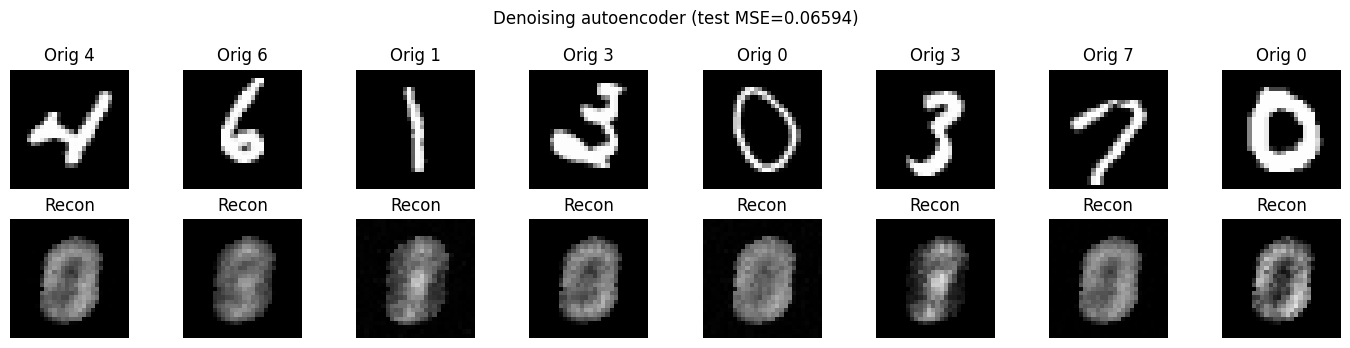

In [13]:
# Visualize denoising autoencoder reconstructions vs originals
plot_reconstructions(

    autoencoder_denoise, X_test, y_test,

    title=f"Denoising autoencoder (test MSE={mse_denoise:.5f})",

)


---

## 9. Compare All Models

Lower **test MSE** means better reconstruction on unseen digits.


Autoencoder reconstruction comparison (lower MSE is better):


,Model,Test MSE,Epochs
0,Sparse overcomplete,0.056005,6
1,Overcomplete + Dropout,0.056936,6
2,First undercomplete (784→32→784),0.058224,10
3,Two-layer linear,0.059753,6
4,Denoising,0.065941,6
5,Nonlinear ReLU,0.066235,6


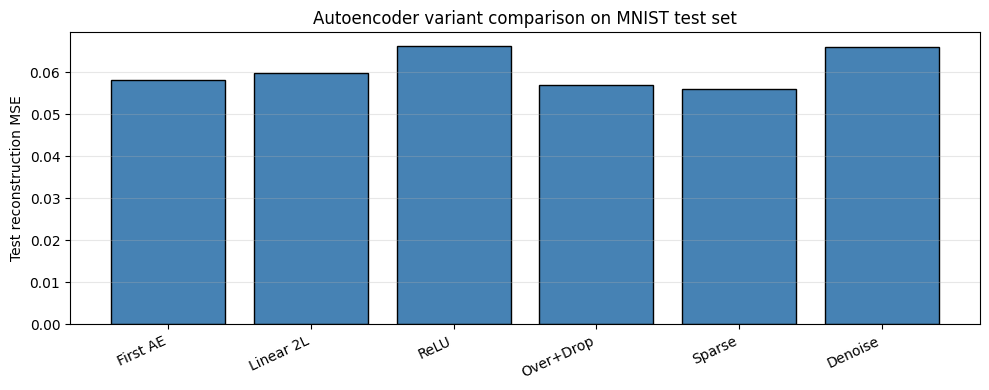

In [14]:
# Build comparison table of test reconstruction MSE across all trained variants
results = pd.DataFrame([

    {"Model": "First undercomplete (784→32→784)", "Test MSE": mse_v1, "Epochs": EPOCHS_MAIN},

    {"Model": "Two-layer linear", "Test MSE": mse_linear2, "Epochs": EPOCHS_VARIANT},

    {"Model": "Nonlinear ReLU", "Test MSE": mse_relu, "Epochs": EPOCHS_VARIANT},

    {"Model": "Overcomplete + Dropout", "Test MSE": mse_over_dropout, "Epochs": EPOCHS_VARIANT},

    {"Model": "Sparse overcomplete", "Test MSE": mse_sparse, "Epochs": EPOCHS_VARIANT},

    {"Model": "Denoising", "Test MSE": mse_denoise, "Epochs": EPOCHS_VARIANT},

])

# Sort by test MSE ascending — best reconstructions at top
results = results.sort_values("Test MSE").reset_index(drop=True)

results["Test MSE"] = results["Test MSE"].map(lambda v: f"{v:.6f}")

print("Autoencoder reconstruction comparison (lower MSE is better):")

display(results)

# Bar chart of test MSE values
mse_values = [mse_v1, mse_linear2, mse_relu, mse_over_dropout, mse_sparse, mse_denoise]

model_names = ["First AE", "Linear 2L", "ReLU", "Over+Drop", "Sparse", "Denoise"]

plt.figure(figsize=(10, 4))

plt.bar(model_names, mse_values, color="steelblue", edgecolor="black")

plt.ylabel("Test reconstruction MSE")

plt.title("Autoencoder variant comparison on MNIST test set")

plt.xticks(rotation=25, ha="right")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()


---

## 10. Glossary — All Chapter 8 Terms

| Term | One-line definition |
|------|---------------------|
| **Autoencoder** | Neural network trained to reconstruct its input |
| **Encoder / Decoder** | Compress input to latent code / expand back to output |
| **Undercomplete** | Bottleneck smaller than input dimension |
| **Overcomplete** | Bottleneck as large or larger than needed — needs regularization |
| **MSE (Mean Squared Error)** | Average squared pixel difference — reconstruction loss |
| **Adam optimizer** | Adaptive gradient descent optimizer |
| **ReLU (Rectified Linear Unit)** | Activation max(0, x) — introduces nonlinearity |
| **Sigmoid activation** | Squashes output to (0, 1) — matches scaled pixels |
| **Dropout** | Randomly drops units during training to reduce overfitting |
| **Activity regularizer** | Penalty on layer activations — encourages sparsity |
| **Sparse autoencoder** | Few hidden units active per input |
| **Denoising autoencoder** | Reconstructs clean data from noisy corrupted input |
| **GaussianNoise layer** | Adds random noise to input during training only |
| **Train/test split** | Hold out unseen data to measure generalization |
| **Reconstruction error** | How far reconstructed output is from original input |


---

## 11. Chapter 8 Summary

```
Hands-On Autoencoder (Chapter 8) — MNIST
├── Prepare data: scale [0,1] → train/test split
├── First AE: 784 → 32 → 784 (MSE + Adam)
├── Variants
│   ├── Two-layer linear undercomplete
│   ├── Nonlinear ReLU
│   ├── Overcomplete + Dropout
│   ├── Sparse (activity regularizer)
│   └── Denoising (GaussianNoise)
├── Evaluate test reconstruction MSE
└── Visualize original vs reconstructed digits

Lower MSE = sharper reconstructions on unseen images
```

### What's next?

**Chapter 9** combines supervised and unsupervised models in **semisupervised learning**.

---

### Practice questions

1. Why do we use sigmoid on the output layer when pixels are scaled to [0, 1]?
2. Which variant gave the lowest test MSE in your run, and why might that architecture help?
3. How does dropout change behavior during training vs inference in the overcomplete model?
4. Why does the denoising autoencoder take clean digits as targets but may add noise inside the network?
5. What would happen if you used an overcomplete autoencoder **without** dropout or sparsity penalties?
